# Customer Segmentation EDA
Explores user behavior patterns using pandas groupby aggregations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

## Load Data
Loading the combined instacart dataset.

In [2]:
df = pd.read_csv('../../data/combined_instacart_data.csv', usecols=['user_id', 'order_number', 'days_since_prior_order', 'add_to_cart_order', 'reordered', 'order_dow', 'order_hour_of_day'])
df['days_since_prior_order'] = df['days_since_prior_order'].fillna(0)

## Distribution of Days Since Prior Order
Plotting a histogram and marking the 75th percentile as the dormancy threshold.

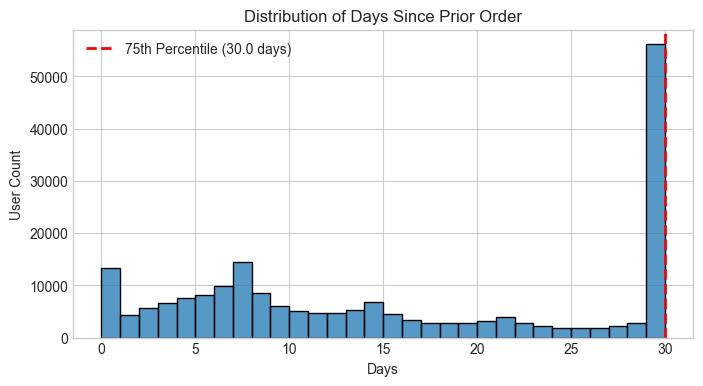

In [3]:
user_recency = df.groupby('user_id')['days_since_prior_order'].last().reset_index()
dormancy_threshold = user_recency['days_since_prior_order'].quantile(0.75)

plt.figure(figsize=(8, 4))
sns.histplot(user_recency['days_since_prior_order'], bins=30, kde=False)
plt.axvline(dormancy_threshold, color='red', linestyle='dashed', linewidth=2, label=f'75th Percentile ({dormancy_threshold:.1f} days)')
plt.title('Distribution of Days Since Prior Order')
plt.xlabel('Days')
plt.ylabel('User Count')
plt.legend()
plt.show()

## Distribution of Total Orders (Frequency)
Histogram of total orders per user.

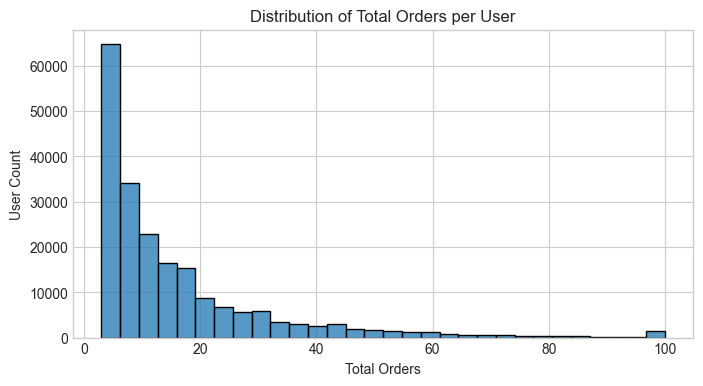

In [4]:
user_frequency = df.groupby('user_id')['order_number'].max().reset_index()
plt.figure(figsize=(8, 4))
sns.histplot(user_frequency['order_number'], bins=30, kde=False)
plt.title('Distribution of Total Orders per User')
plt.xlabel('Total Orders')
plt.ylabel('User Count')
plt.show()

## Average Basket Size per User
Histogram of average basket size.

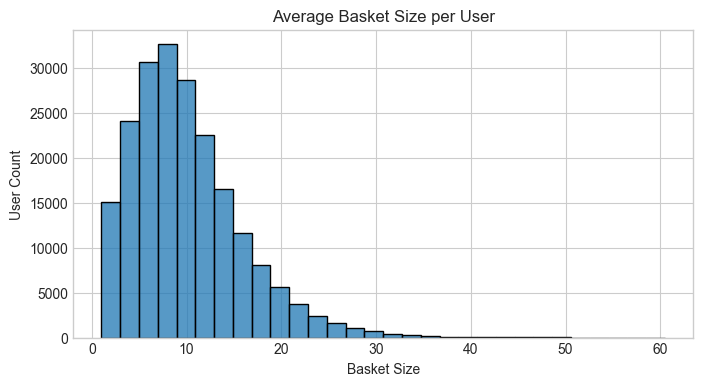

In [5]:
basket_sizes = df.groupby(['user_id', 'order_number'])['add_to_cart_order'].max().reset_index()
avg_basket = basket_sizes.groupby('user_id')['add_to_cart_order'].mean().reset_index(name='avg_basket_size')

plt.figure(figsize=(8, 4))
sns.histplot(avg_basket['avg_basket_size'], bins=30, kde=False)
plt.title('Average Basket Size per User')
plt.xlabel('Basket Size')
plt.ylabel('User Count')
plt.show()

## Average Reorder Rate per User
Histogram of user reorder rates.

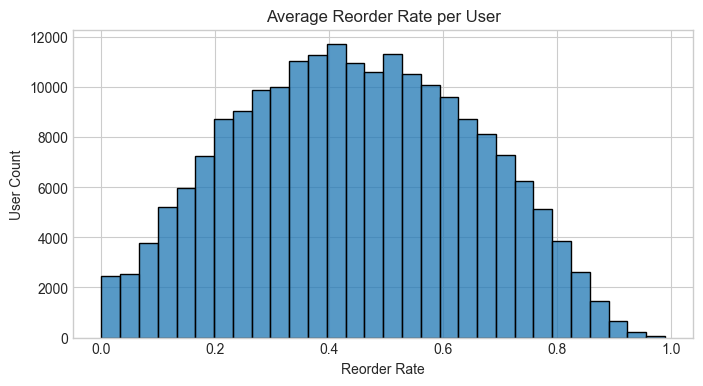

In [6]:
reorder_rate = df.groupby('user_id')['reordered'].mean().reset_index(name='avg_reorder_rate')

plt.figure(figsize=(8, 4))
sns.histplot(reorder_rate['avg_reorder_rate'], bins=30, kde=False)
plt.title('Average Reorder Rate per User')
plt.xlabel('Reorder Rate')
plt.ylabel('User Count')
plt.show()

## Orders by DOW and Hour
Finding preferred shopping days and times.

In [7]:
dow_pref = df.groupby('user_id')['order_dow'].apply(lambda x: x.mode()[0]).reset_index(name='preferred_dow')
hour_pref = df.groupby('user_id')['order_hour_of_day'].apply(lambda x: x.mode()[0]).reset_index(name='preferred_hour')

## Recency vs Frequency
Scatter plot to visually show user clusters before K-Means.

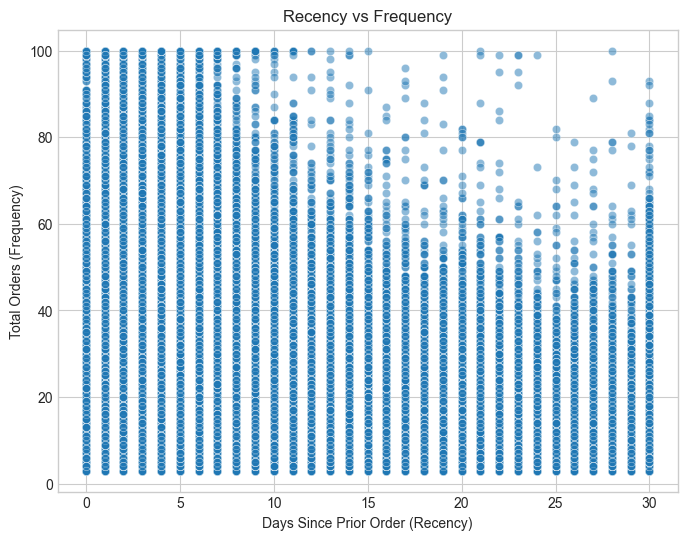

In [8]:
user_features = user_recency.merge(user_frequency, on='user_id')
plt.figure(figsize=(8, 6))
sns.scatterplot(data=user_features, x='days_since_prior_order', y='order_number', alpha=0.5)
plt.title('Recency vs Frequency')
plt.xlabel('Days Since Prior Order (Recency)')
plt.ylabel('Total Orders (Frequency)')
plt.show()

## Rule-based Dormancy Check
Flag users where recency > 75th percentile AND frequency > 3.

In [9]:
user_features = user_features.merge(avg_basket, on='user_id').merge(reorder_rate, on='user_id').merge(dow_pref, on='user_id').merge(hour_pref, on='user_id')
user_features['is_dormant_rule'] = (user_features['days_since_prior_order'] > dormancy_threshold) & (user_features['order_number'] > 3)
user_features.to_csv('../../data/precomputed/user_features.csv', index=False)
print('Exported user_features.csv')

Exported user_features.csv
